# Mercari(일본 중고거래 플랫폼) 가격 예측 프로젝트

## 프로젝트 흐름  
1. 환경 설정 및 데이터 로드
2. 데이터 전처리 (카테고리 분리, 결측치 처리)
3. 텍스트 특징 추출 (NLP_자연어 처리)
4. 새로운 피처 생성
5. 모델 학습
6. 가격 예측 & 제출  

### 1. 환경설정 및 데이터 로드

In [2]:
pip install pandas numpy scikit-learn lightgbm nltk scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
# 1. 환경설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# 1. 데이터 로드
train = pd.read_csv('train.tsv', sep='\t')
test  = pd.read_csv('test.tsv',  sep='\t')

print(train.shape)
print(train.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\master\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\master\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\master\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


(1482535, 8)
   train_id                                 name  item_condition_id  \
0         0  MLB Cincinnati Reds T Shirt Size XL                  3   
1         1     Razer BlackWidow Chroma Keyboard                  3   
2         2                       AVA-VIV Blouse                  1   
3         3                Leather Horse Statues                  1   
4         4                 24K GOLD plated rose                  1   

                                       category_name brand_name  price  \
0                                  Men/Tops/T-shirts        NaN   10.0   
1  Electronics/Computers & Tablets/Components & P...      Razer   52.0   
2                        Women/Tops & Blouses/Blouse     Target   10.0   
3                 Home/Home Décor/Home Décor Accents        NaN   35.0   
4                            Women/Jewelry/Necklaces        NaN   44.0   

   shipping                                   item_description  
0         1                                 No des

### 2. 데이터 전처리 (결측치, 이상치)

In [11]:
# 전체 결측치 현황 한눈에 보기
print("=== 결측치 현황 ===")
print(train.isna().sum())

=== 결측치 현황 ===
train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64


In [12]:
# 세부 컬럼별 결측치 확인
# 'category_name' 컬럼

print(f"\n▣ category_name 결측치 수: {train['category_name'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['category_name'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_category = train[train['category_name'].isna()][
    ['name', 'brand_name', 'item_description', 'price']
].sample(20, random_state=42)

print("\n=== category_name 결측 샘플 ===")
print(null_category.to_string())


▣ category_name 결측치 수: 6327
▣ 전체 대비 비율: 0.43%

=== category_name 결측 샘플 ===
                                             name      brand_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         item_description  price
245817                             Mini deep dome         Zoo Med                                                                                                                                                                                                         

In [13]:
# 'brand_name' 컬럼

print(f"\n▣ brand_name 결측치 수: {train['brand_name'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['brand_name'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_brand = train[train['brand_name'].isna()][
    ['name', 'category_name', 'item_description', 'price']
].sample(20, random_state=42)

print("\n=== brand_name 결측 샘플 ===")
print(null_brand.to_string())


▣ brand_name 결측치 수: 632682
▣ 전체 대비 비율: 42.68%

=== brand_name 결측 샘플 ===
                                             name                                   category_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                    item_description  price
519130                  Perfume & necklace Bundle                          Beauty/Fragrance/Women                                                                                                                                                                                                                                                                 

In [14]:
# 'item_description' 컬럼

print(f"\n▣ item_description 결측치 수: {train['item_description'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['item_description'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_description = train[train['item_description'].isna()][
    ['name', 'category_name', 'brand_name', 'price']
].sample(6, random_state=42)

print("\n=== item_description 결측 샘플 ===")
print(null_description.to_string())


▣ item_description 결측치 수: 6
▣ 전체 대비 비율: 0.00%

=== item_description 결측 샘플 ===
                            name                                   category_name           brand_name  price
321916        Lululemon leggings  Women/Athletic Apparel/Pants, Tights, Leggings  lululemon athletica   44.0
511535        Shoes for Michelle                       Kids/Girls 0-24 Mos/Shoes                  NaN    9.0
1425077            Lg 25um65p x2                         Electronics/Other/Other                  NaN  230.0
861230                  Lipgloss                              Beauty/Makeup/Lips                  NaN   49.0
1264242               For Bianca       Women/Women's Accessories/Scarves & Wraps                  NaN   10.0
1224924  Disney Minnie Head band      Women/Women's Accessories/Hair Accessories               Disney    9.0


In [15]:
# 'item_description' 결측치 : 'No description yet'과 동일한 값으로 처리
train['item_description'] = train['item_description'].fillna("No description yet")

In [16]:
# 'brand_name' 결측치 처리 :
# 1. 기존 브랜드명이 기재된 컬럼에는 1, 누락된 곳에는 0
# 2. 결측치처리 : 'No Brand'
train["has_brand"] = train["brand_name"].notna().astype(int)
train["brand_name"] = train["brand_name"].fillna("No Brand")

In [17]:
# 'category_name' 결측치 처리 : 'No Category/No category/No category' - 기존 카테고리 분류 형식과 동일하게
train["category_name"] = train["category_name"].fillna("No category/No category/No category")

In [18]:
# 카테고리 분리 적용
train[['cat_1', 'cat_2', 'cat_3']] = train['category_name'].str.split('/', n=2, expand=True)

print(train['cat_1'].value_counts().head(15))  # 상위 카테고리 확인 : 카테고리 미분류 항목 포함 총 11개 대분류

cat_1
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
No category                 6327
Name: count, dtype: int64


In [19]:
# 원본 결측 위치 저장
no_category = train[train['category_name'] == 'No category/No category/No category'].copy()
no_brand    = train[train['brand_name'] == 'No Brand'].copy()

print(f"카테고리 없는 상품 수: {len(no_category)}")
print(f"브랜드 없는 상품 수: {len(no_brand)}")

카테고리 없는 상품 수: 6327
브랜드 없는 상품 수: 632682


In [20]:
# 처리 후 전체 결측치 현황 한눈에 보기
print("=== 결측치 처리 후 데이터 결측치 현황 ===")
print(train.isna().sum())

=== 결측치 처리 후 데이터 결측치 현황 ===
train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
has_brand            0
cat_1                0
cat_2                0
cat_3                0
dtype: int64


In [21]:
# 가격이 '0'인 상품 저장
zero_price = train[train['price'] == 0].copy()

In [22]:
zero_price.head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand,cat_1,cat_2,cat_3
1325,1325,Alabama Crimson Tide Quality Lanyard,1,Sports & Outdoors/Fan Shop/NCAA,No Brand,0.0,1,TOP QUALITY THICK LANYARD Reversible sides wit...,0,Sports & Outdoors,Fan Shop,NCAA
2544,2544,Levi leggings,3,"Women/Jeans/Slim, Skinny",Levi's®,0.0,0,Light wash. Hardly worn. Size 24 but fits like...,1,Women,Jeans,"Slim, Skinny"
2712,2712,Simple Red Lace Lingerie Top,3,Women/Underwear/G-Strings & Thongs,No Brand,0.0,0,"Very simple but cute, a little form fitting as...",0,Women,Underwear,G-Strings & Thongs
3576,3576,Turquoise 15 Pc Makeup Brush Set,1,Beauty/Tools & Accessories/Makeup Brushes & Tools,No Brand,0.0,1,1 left!,0,Beauty,Tools & Accessories,Makeup Brushes & Tools
3761,3761,Girls size 7/8,3,Kids/Girls (4+)/Tops & T-Shirts,No Brand,0.0,1,5 pair gap jean excellent used condition 3 chi...,0,Kids,Girls (4+),Tops & T-Shirts


### 3. 기초 EDA  

#### 3-1. 수치형 컬럼  

##### 3-1-1. 단변량 분석

In [23]:
# 수치형 컬럼 선택
numeric_cols = ['item_condition_id', 'price', 'shipping']

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_10000\1459118678.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='shipping', data=train, ax=axes[4], palette='pastel')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_10000\1459118678.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[4].set_xticklabels(['Buyer pays (0)', 'Seller pays (1)'])


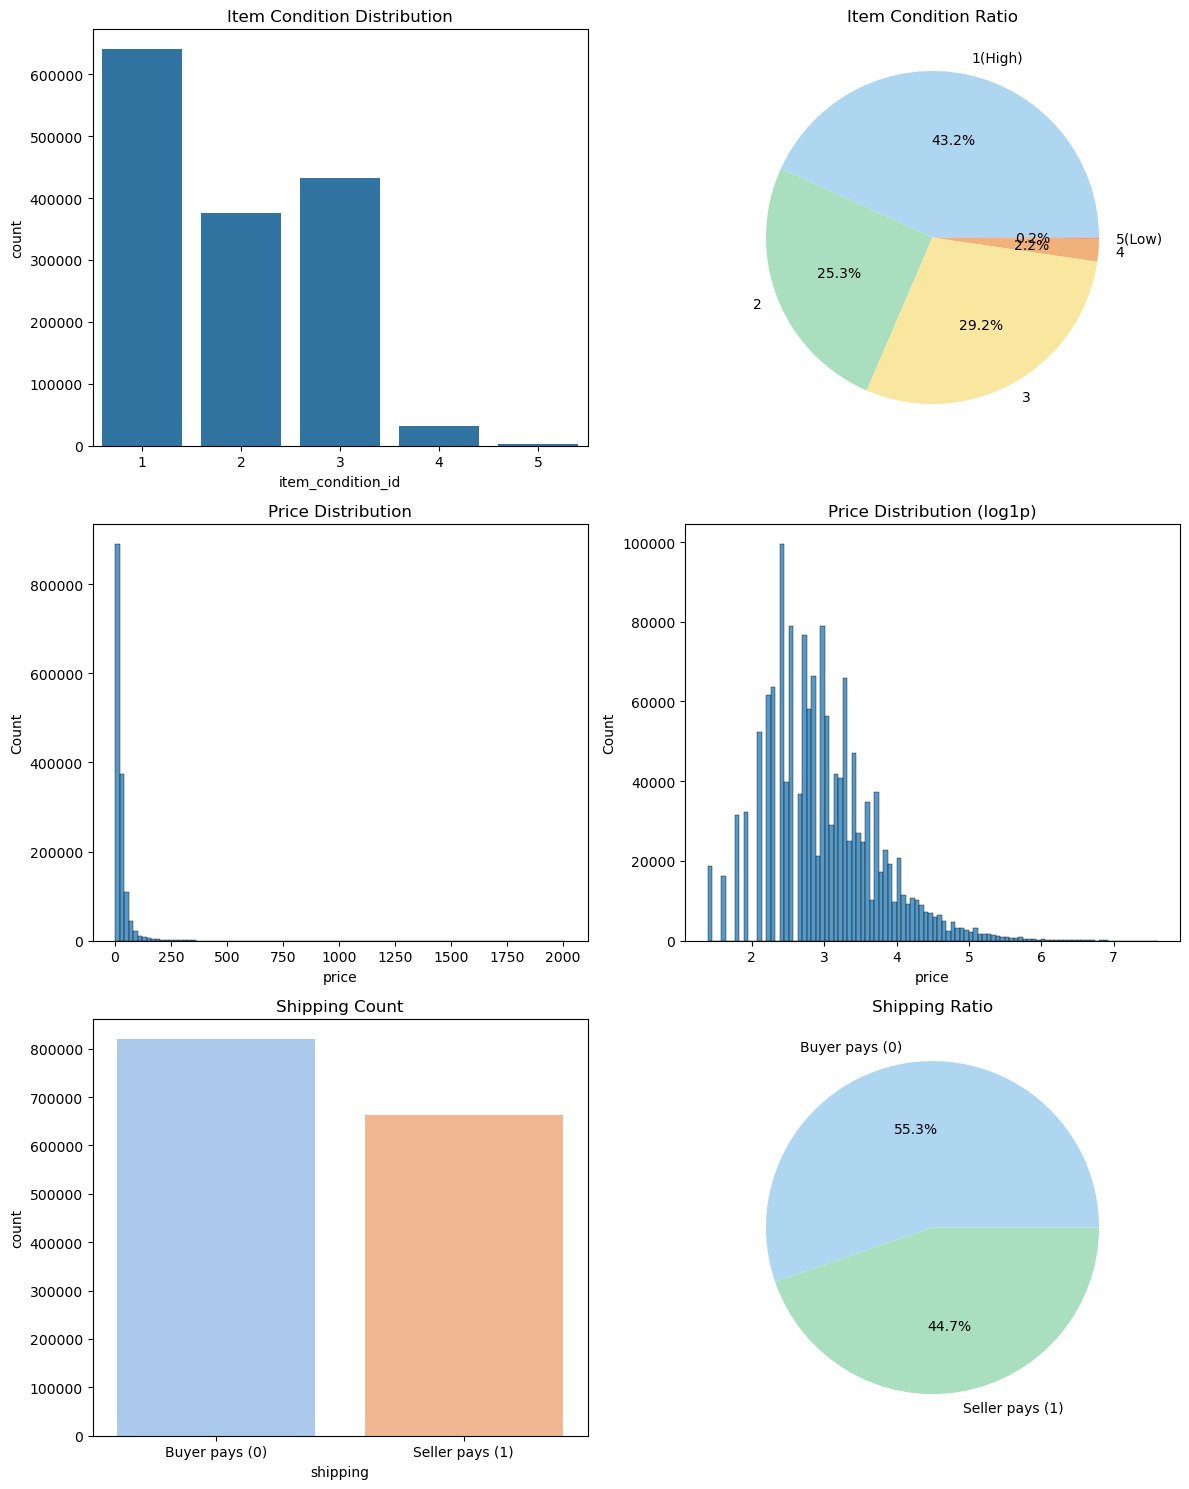

In [24]:
# 수치형 컬럼의 시각화

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()

# item_condition_id: 카테고리형과 유사 -> countplot
sns.countplot(x='item_condition_id', data=train, ax=axes[0])
axes[0].set_title('Item Condition Distribution')

# item_condition_id 비율 확인 : pie-chart
condition_counts = train['item_condition_id'].value_counts().sort_index()
axes[1].pie(condition_counts, 
            labels=['1(High)', '2', '3', '4', '5(Low)'],
            autopct='%1.1f%%', 
            colors=['#AED6F1', '#A9DFBF', '#F9E79F', '#F0B27A', '#F1948A'])
axes[1].set_title('Item Condition Ratio')

# price: 가격은 보통 심하게 오른쪽으로 치우쳐 있음 (right-skewed)
sns.histplot(train['price'], bins=100, ax=axes[2])
axes[2].set_title('Price Distribution')

# price 로그 변환
sns.histplot(train['price'][train['price'] > 0].apply(np.log1p), bins=100, ax=axes[3])
axes[3].set_title('Price Distribution (log1p)')

# shipping : 카테고리형과 유사 -> Countplot (절대적인 빈도 확인)
sns.countplot(x='shipping', data=train, ax=axes[4], palette='pastel')
axes[4].set_title('Shipping Count')
axes[4].set_xticklabels(['Buyer pays (0)', 'Seller pays (1)'])

# shipping 비율 확인 : Pie chart
shipping_counts = train['shipping'].value_counts()
axes[5].pie(shipping_counts, 
            labels=['Buyer pays (0)', 'Seller pays (1)'],
            autopct='%1.1f%%', 
            colors=['#AED6F1', '#A9DFBF'])
axes[5].set_title('Shipping Ratio')

plt.tight_layout()
plt.show()

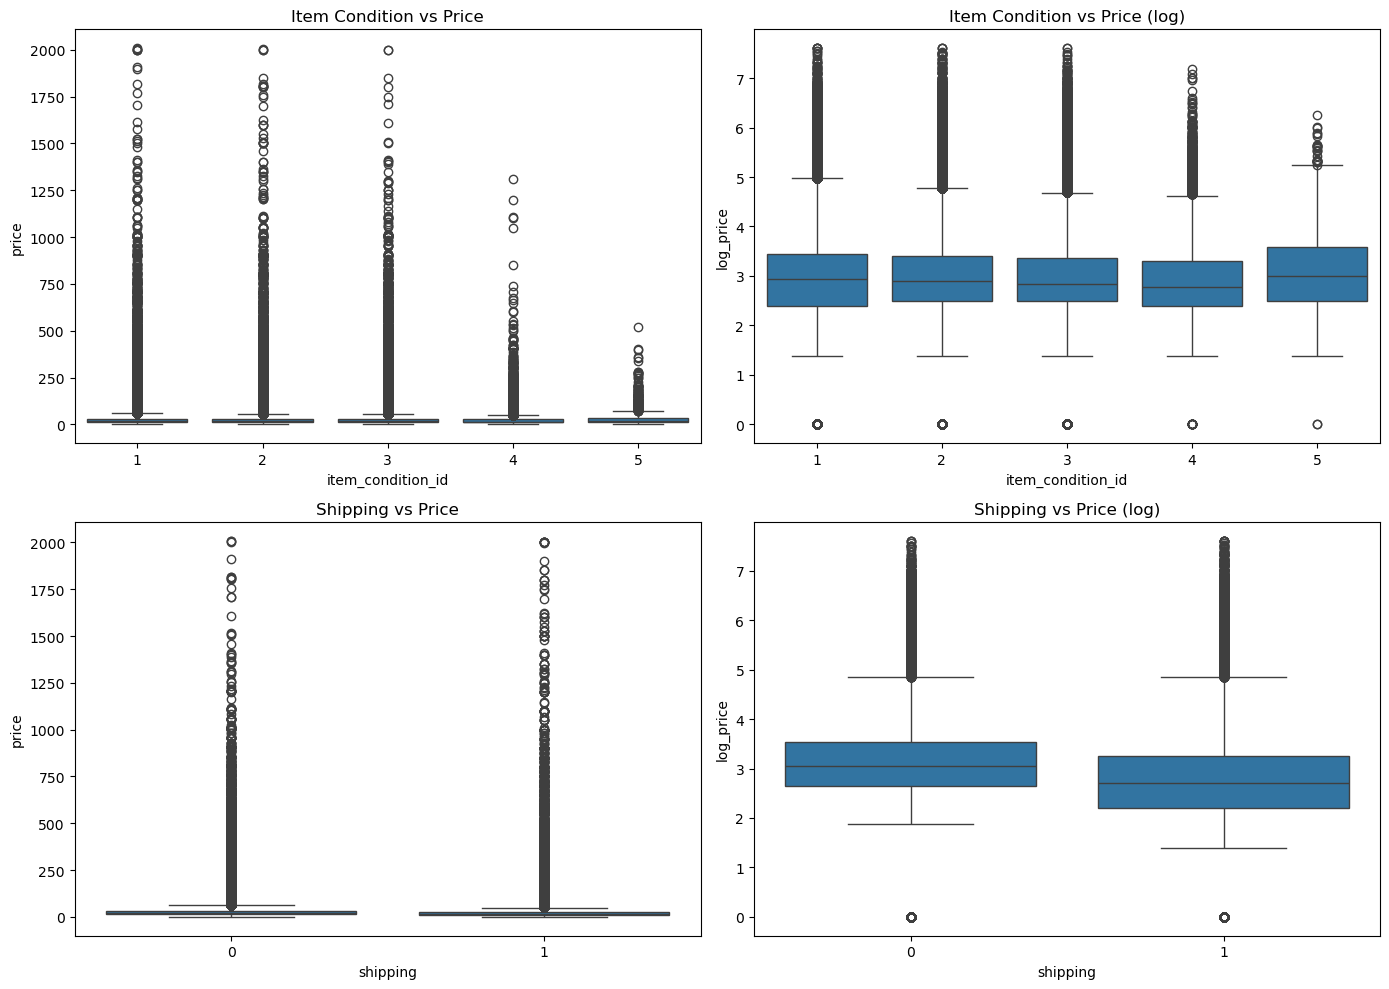

In [25]:
# price와 'item_condition_id', 'shipping' 사이의 이변량 분석

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# price 로그변환 컬럼 생성
train['log_price'] = np.log1p(train['price'])

# item_condition_id - 원본 price
sns.boxplot(x='item_condition_id', y='price', data=train, ax=axes[0][0])
axes[0][0].set_title('Item Condition vs Price')

# item_condition_id - log price (왜도 보정)
sns.boxplot(x='item_condition_id', y='log_price', data=train, ax=axes[0][1])
axes[0][1].set_title('Item Condition vs Price (log)')

# shipping - 원본 price
sns.boxplot(x='shipping', y='price', data=train, ax=axes[1][0])
axes[1][0].set_title('Shipping vs Price')

# shipping - log price
sns.boxplot(x='shipping', y='log_price', data=train, ax=axes[1][1])
axes[1][1].set_title('Shipping vs Price (log)')

plt.tight_layout()
plt.show()

In [26]:
# boxplot의 중앙값, 평균 확인
print("=== Item Condition별 Price 중앙값 및 평균 ===")
print(train.groupby('item_condition_id')['price'].agg(['median','mean']).round(2))

print("\n=== Shipping별 Price 중앙값 및 평균 ===")
print(train.groupby('shipping')['price'].agg(['median','mean']).round(2))

print("\n=== Item Condition별 log_price 중앙값 및 평균 ===")
print(train.groupby('item_condition_id')['log_price'].agg(['median','mean']).round(4))

print("\n=== Shipping별 log_price 중앙값 및 평균 ===")
print(train.groupby('shipping')['log_price'].agg(['median','mean']).round(4))

=== Item Condition별 Price 중앙값 및 평균 ===
                   median   mean
item_condition_id               
1                    18.0  26.49
2                    17.0  27.56
3                    16.0  26.54
4                    15.0  24.35
5                    19.0  31.70

=== Shipping별 Price 중앙값 및 평균 ===
          median   mean
shipping               
0           20.0  30.11
1           14.0  22.57

=== Item Condition별 log_price 중앙값 및 평균 ===
                   median    mean
item_condition_id                
1                  2.9444  2.9727
2                  2.8904  3.0007
3                  2.8332  2.9752
4                  2.7726  2.8960
5                  2.9957  3.0925

=== Shipping별 log_price 중앙값 및 평균 ===
          median    mean
shipping                
0         3.0445  3.1339
1         2.7081  2.7877


##### 3-1-2. 이변량 분석 - item_condition_id(상품 컨디션)와 shipping(배송비) 관계 확인

In [27]:
# 교차표 - 빈도수
print("=== Item Condition x Shipping 교차표 (빈도) ===")
print(pd.crosstab(train['item_condition_id'], train['shipping']))

# 교차표 - 비율 (행 기준, 각 컨디션별 shipping 비율)
print("\n=== Item Condition x Shipping 교차표 (행 기준 비율) ===")
print(pd.crosstab(train['item_condition_id'], train['shipping'], normalize='index').round(4))

=== Item Condition x Shipping 교차표 (빈도) ===
shipping                0       1
item_condition_id                
1                  280107  360442
2                  232509  142970
3                  283691  148470
4                   21603   10359
5                    1525     859

=== Item Condition x Shipping 교차표 (행 기준 비율) ===
shipping                0       1
item_condition_id                
1                  0.4373  0.5627
2                  0.6192  0.3808
3                  0.6564  0.3436
4                  0.6759  0.3241
5                  0.6397  0.3603


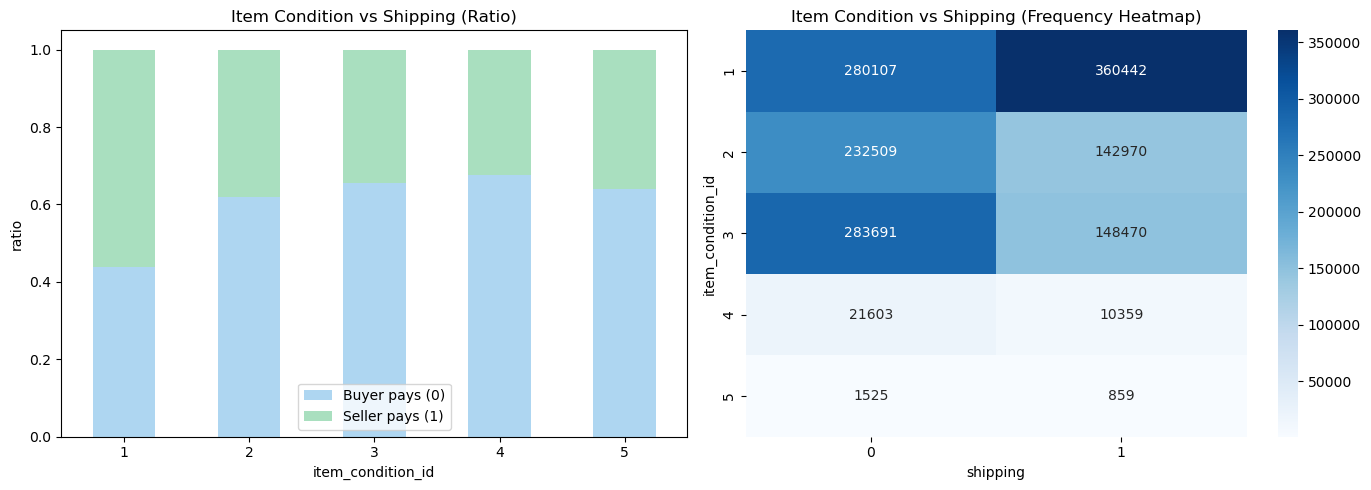

In [28]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 누적 막대그래프 - 컨디션별 shipping 비율 비교
ct = pd.crosstab(train['item_condition_id'], train['shipping'], normalize='index')
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#AED6F1', '#A9DFBF'])
axes[0].set_title('Item Condition vs Shipping (Ratio)')
axes[0].set_xlabel('item_condition_id')
axes[0].set_ylabel('ratio')
axes[0].legend(['Buyer pays (0)', 'Seller pays (1)'])
axes[0].tick_params(axis='x', rotation=0)

# 2. 히트맵 - 빈도수 기반
ct_count = pd.crosstab(train['item_condition_id'], train['shipping'])
sns.heatmap(ct_count, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Item Condition vs Shipping (Frequency Heatmap)')

plt.tight_layout()
plt.show()

##### 3-1-3. **수치형 컬럼에 대한 분석 결과 요약**  

- 'item_condition_id' :   
    1. 판매하고자 하는 상품의 상태는 1(High)에서 5(Low)의 5단계로 분류되어 있다.     
    2. 물품의 품질이 높은 상태(1)인 경우가 전체의 43.2%를 차지하며, 3(29.2%) → 2(25.3%) → 4(2.2%) → 5(0.2%) 순으로 나타난다.     
    3. 전반적으로 컨디션이 좋은 상품일 수록 가격이 높은 경향을 확인할 수 있다. (1-3등급에서 1,500 이상의 고가 상품의 분포를 확인할 수 있다.)   
    4. 컨디션이 5인 상품의 중앙값이 가장 높은 결과를 토대로 낮은 컨디션 상품도 의외로 가격이 낮지 않은 경우가 많다는 것을 확인할 수 있다.  
    5. 상품의 컨디션보다 다른 요소가 가격에 더 큰 영향을 줄 수 있다는 것을 반증한다.   
    6. 컨디션이 1-3에 판매 상품이 집중되어 있는 것을 히트맵을 통해서 확인할 수 있다. 
- 'price' :   
    1. 전체 상품의 평균은 26.7375이며 중앙값은 17이다. std는 38.58607로 가격이 넓게 분포된 것을 확인할 수 있다.   
    2. 원본 price의 그래프에서 보이듯 가격은 오른쪽으로 심하게 치우쳐 있음을 확인할 수 있다.  
- 'shipping' :   
    1. 배송비(shipping)과 가격(price)의 상관관계에 있어서, 배송비가 구매자 부담(0)인 경우, 중앙값이 20으로 판매자 부담(1)인 경우(14)보다 높다.   
    2. 판매자가 배송비를 포함하여 가격을 책정하는 전략을 사용하거나, 저가 상품 판매에 있어 판매자가 배송비를 부담하는 경향이 있음을 확인할 수 있다.  
    3. 상품의 컨디션이 가장 좋은 상품(item_condition_id : 1)에서만 판매자의 배송비 부담비율이 과반수를 넘는다. 나머지 등급에서는 소비자의 배송비 부담이 60%대로 더 높은 경향을 확인할 수 있다.    
    4. 컨디션 1인 상품에 있어서 판매자가 배송비를 부담하는 건수는 360,442건으로 전체 데이터 1,482,535건 중 24.31%를 차지하는 것으로 전체에서 가장 큰 비중을 차지하고 있음을 확인할 수 있다.   

**💡[Insights]**  
- 'item_condition_id' x 'shipping' 조합 고려 : 상품의 컨디션과 배송비간의 상호관계에 대한 추가 범주형 데이터 설정 및 분석   
- 방향 : 단순 조합
- 코드 : train['condition_x_shipping'] = train['item_condition_id'].astype(str) + '_' + train['shipping'].astype(str)  
- 결과 예시: '1_0', '1_1', '2_0', '2_1' ... 총 10가지 조합 

#### 3-2. 범주형 컬럼  

##### 3-2-1. 단변량 분석

In [29]:
print("=== 범주형 컬럼 기본 현황 ===")
cat_cols = ['name', 'category_name', 'brand_name', 'item_description']
for col in cat_cols:
    print(f"{col}: 고유값 {train[col].nunique():,}개")

=== 범주형 컬럼 기본 현황 ===
name: 고유값 1,225,273개
category_name: 고유값 1,288개
brand_name: 고유값 4,810개
item_description: 고유값 1,281,425개


**💡[Insights]**  
- 'name'과 'item_description' 컬럼  
    : 고유값의 개수가 'name' 컬럼의 경우, 1,225,273개(전체 데이터의 82.65%)이고 'item_description' 컬럼의 경우, 1,281,425개(전체 데이터의 86.43%)를 나타낸다. 전반적으로 개개의 데이터에 포함되어 있는 정보를 텍스트 길이나 자연어 분석을 통하여 상품 가격에 영향을 미치는 요소를 찾는다.     
- 'category_name'과 'brand_name' 컬럼 (결측치 'No category/No category/No category', 'No Brand' 포함) 
    : 각 컬럼의 개수가 'category_name' 컬럼의 경우, 1,288개, 'brand_name' 컬럼의 경우 4,810개로 고유값으로 그룹화가 가능한 것을 확인할 수 있다.   
      이 두 개의 컬럼에 있어, 상위 30개의 목록을 확인하고, 이에 대한 추가적인 확인을 통하여 가격 예측 변수의 특징을 확인할 수 있다. 

Text(0.5, 1.0, 'Item Description Length Distrubution')

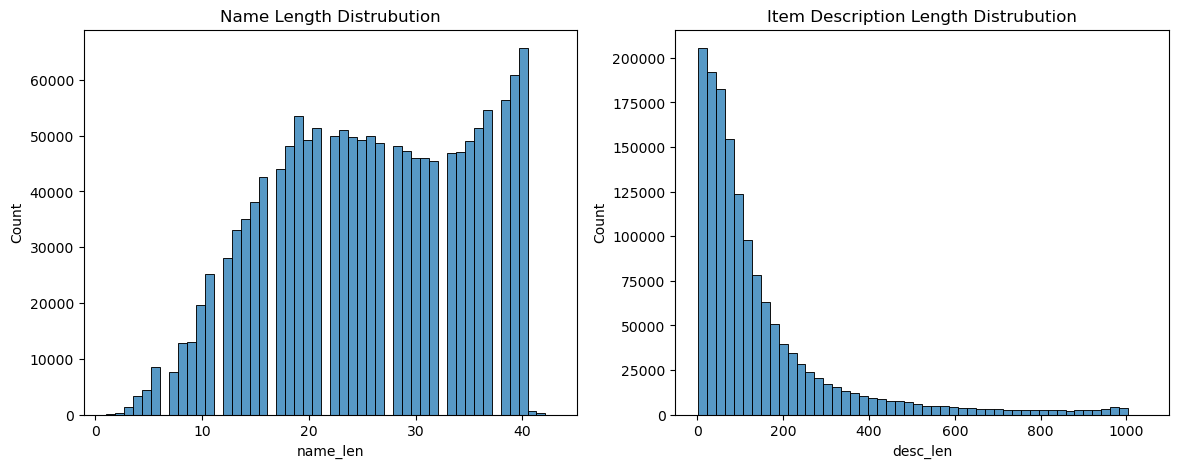

In [30]:
# 'name', 'item_description' 컬럼의 텍스트 길이 분석
train['name_len'] = train['name'].str.len()
train['desc_len'] = train['item_description'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['name_len'], bins=50, ax=axes[0])
axes[0].set_title('Name Length Distrubution')

sns.histplot(train['desc_len'], bins=50, ax=axes[1])
axes[1].set_title('Item Description Length Distrubution')

**💡[Insights]**  
- 'name'의 길이에 따른 상품 분포 :  
    1. 분포가 쌍봉의 형태를 나타낸다. 20자 근처와 40자 근처에서 높은 빈도수를 확인할 수 있다.      
    2. 글자수의 길이에 제한을 추정할 수 있다.  
    3. 판매자에 있어 상품의 설명을 짧게 핵심만 작성하는 유형과 길게 쓰는 판매자의 유형이 존재하는 것을 추정할 수 있다.   
    => 길이 자체를 새로운 feature로 활용 가능
- 'item_description' 길이에 따른 상품 분포 :    
    1. 오른쪽으로 꼬리가 긴 분포를 나타낸다.   
    2. 상품의 설명이 200자 이내에 집중되어 있는 것을 확인할 수 있다.  
    3. 0-20자 구간에 많은 상품이 모여있는 것으로 보아, 해당 구간에 결측치 또는 item_description의 기본값인 'No description yet'으로 기재된 상품의 데이터가 포함되어 있을 가능성이 높게 추정된다.   
       => 확인결과 'No description yet'으로 기재된 데이터수는 82,495개로 전체 데이터의 약 5.56%를 차지한다.   
       => item_description의 길이와 가격과의 상관관계에 대하여 추가 확인이 필요하다.  
       => item_description 유/무가 판매 가격에 영향을 미치는지 여부에 대해서 추가 확인이 필요하다.  

In [31]:
# item_description에 'No description yet'으로 작성된 상품의 개수 및 비율 확인
no_desc = train[train['item_description'] == 'No description yet']
print(f"'No description yet' 개수: {len(no_desc):,}")
print(f"전체 대비 비율: {len(no_desc)/len(train)*100:.2f}%")

'No description yet' 개수: 82,495
전체 대비 비율: 5.56%


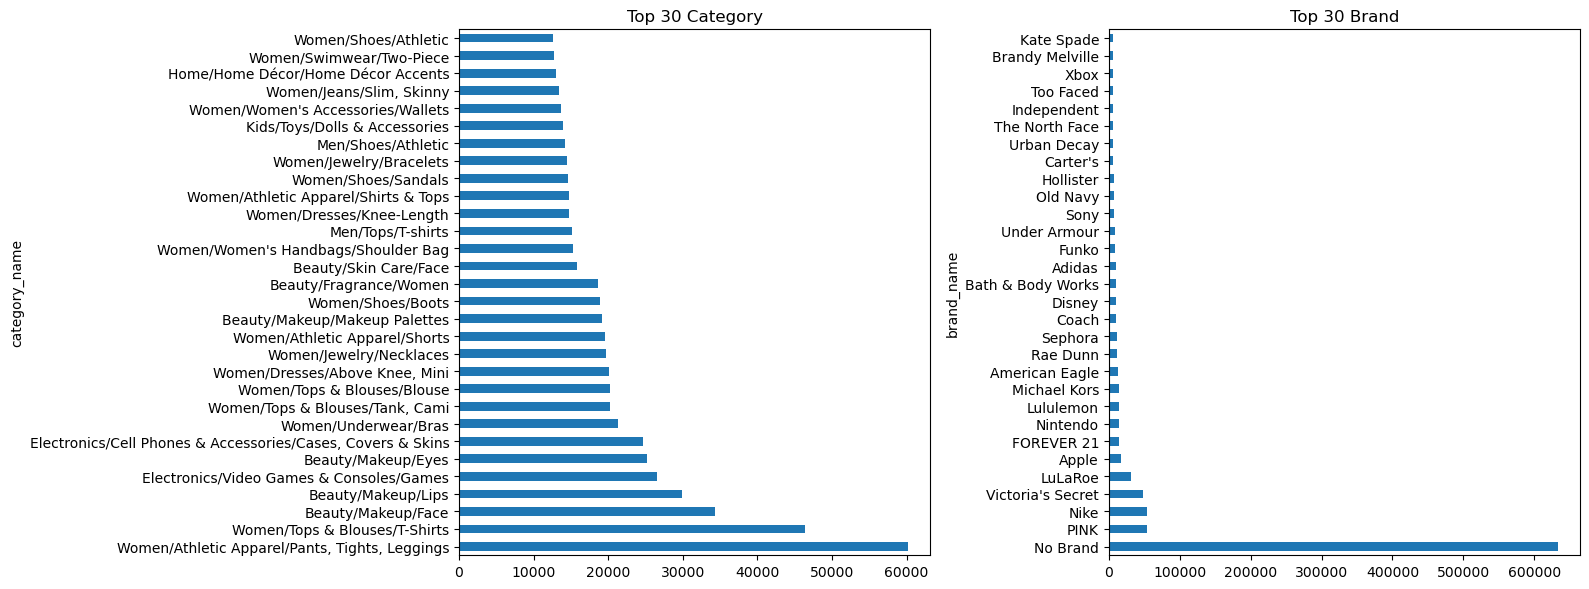

In [32]:
# 'category_name', 'brand_name'의 Top 30 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

train['category_name'].value_counts().head(30).plot(kind='barh', ax=axes[0])
axes[0].set_title('Top 30 Category')

train['brand_name'].value_counts().head(30).plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 30 Brand')

plt.tight_layout()
plt.show()

**💡[Insights]**  
- 'category_name'Top 30 분석 :  
    1. 'Women' 카테고리가 압도적으로 많은 것을 확인할 수 있다. (Top 30개 중 18개)   
    2. 앞서 'Women' 카테고리에 속한 상품의 개수에 있어서 664,385개(전체의 44.81%)로 Mercari 사이트가 여성 사용자 중심 플랫폼임을 추정할 수 있다.  
    3. 'Women'다음으로 'Beauty' 카테고리 상품(207.828개 / 14.01%)가 활발하게 거래되는 것을 확인할 수 있다. 
- 'brand_name' Top 30 분석 :    
    1. 'No Brand'에 속한 상품이 632,682건으로 전체 브랜드 분포에 있어서 압도적으로 우위를 차지하고 있음을 확인할 수 있다.  
    => 전체 데이터의 42.68% 결측치에 대한 확인이 필요한 것을 반증하고 있다.     
    2. 'No Brand'를 제외하고, PINK, Nike, Victoria'secret, LuLaRoe 순으로 앞서 category_name에서 'Women' 카테고리 비중의 차지하는 것과 일치하는 패턴을 확인할 수 있다.    


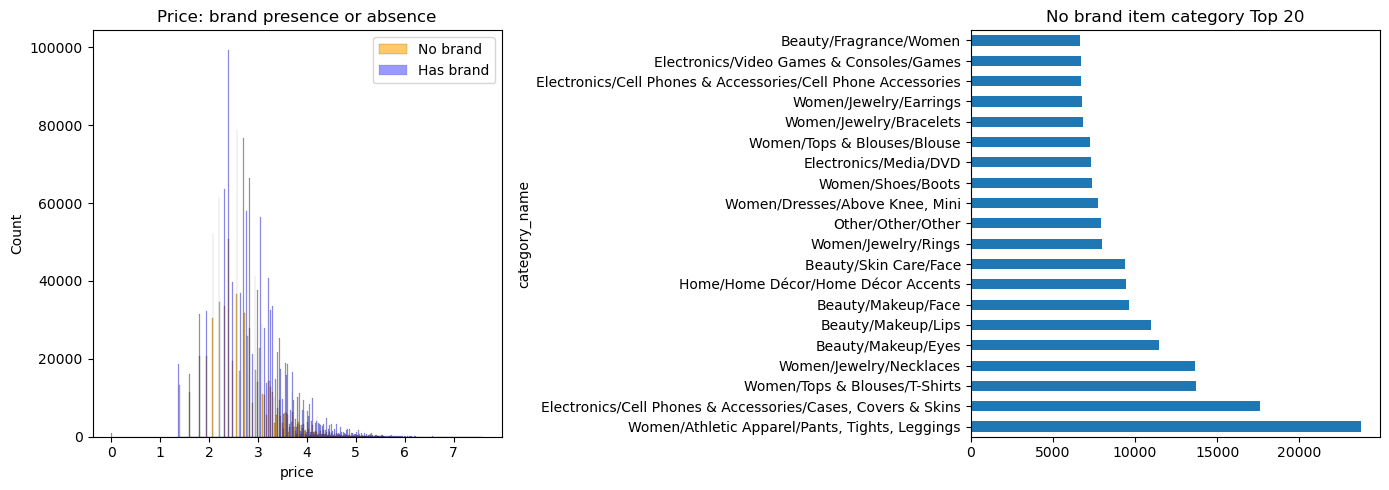

In [33]:
# 브랜드가 없는 상품들의 가격 분포 확인
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(no_brand['price'][no_brand['price'] > 0].apply(np.log1p), 
             ax=axes[0], label='No brand', color='orange', alpha=0.6)
sns.histplot(train[train['brand_name'] != 'No brand']['price'].apply(np.log1p),
             ax=axes[0], label='Has brand', color='blue', alpha=0.4)
axes[0].set_title('Price: brand presence or absence')
axes[0].legend()

# 브랜드 없는 상품의 카테고리 분포
no_brand['category_name'].value_counts().head(20).plot(kind='barh', ax=axes[1])
axes[1].set_title('No brand item category Top 20')

plt.tight_layout()
plt.show()

category_name 분류에 따른 분포

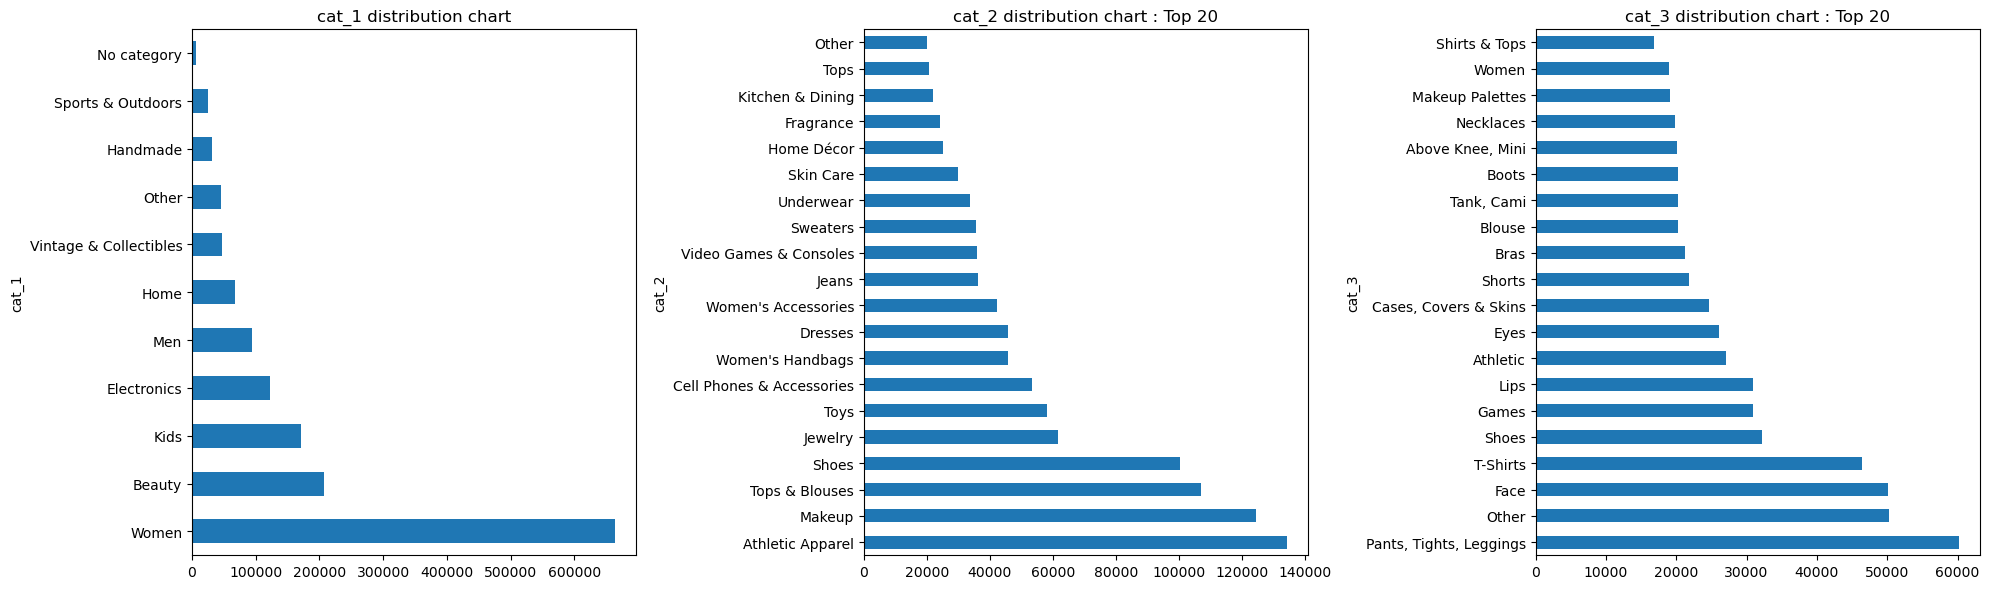

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# cat_1: 대분류
train['cat_1'].value_counts().plot(kind='barh', ax=axes[0])
axes[0].set_title('cat_1 distribution chart')

# cat_2: 중분류 Top 20
train['cat_2'].value_counts().head(20).plot(kind='barh', ax=axes[1])
axes[1].set_title('cat_2 distribution chart : Top 20')

# cat_3: 소분류 Top 20
train['cat_3'].value_counts().head(20).plot(kind='barh', ax=axes[2])
axes[2].set_title('cat_3 distribution chart : Top 20')

plt.tight_layout()
plt.show()

cat_1
Men                       21.0
Women                     19.0
Home                      18.0
No category               16.0
Sports & Outdoors         16.0
Vintage & Collectibles    16.0
Beauty                    15.0
Electronics               15.0
Kids                      14.0
Other                     14.0
Handmade                  12.0
Name: price, dtype: float64


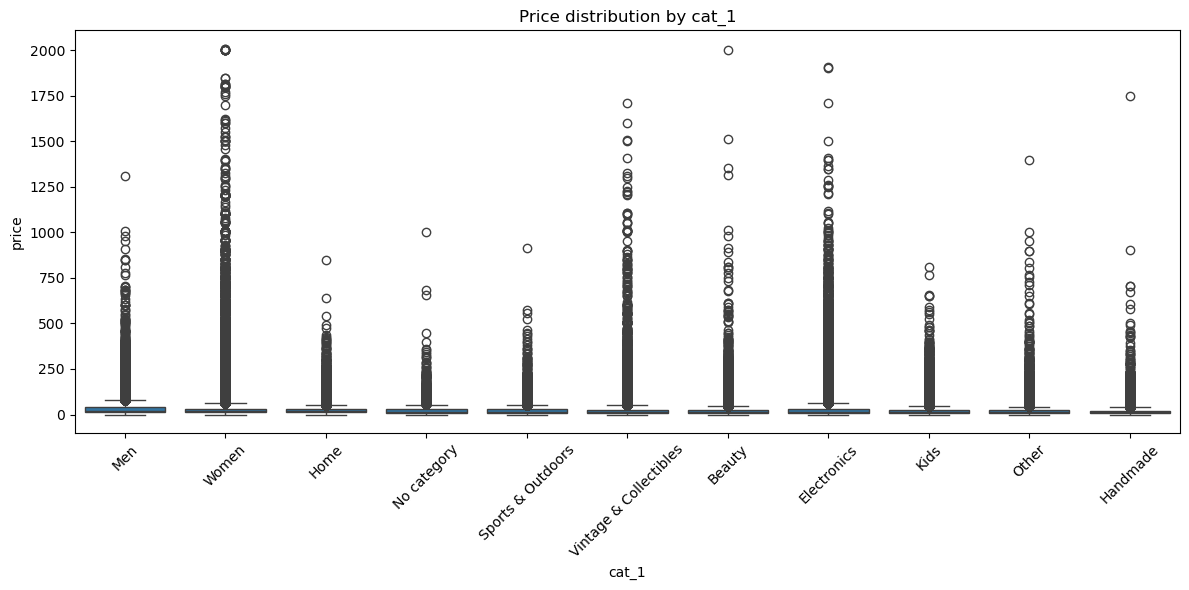

In [35]:
# 대분류 카테고리별 중앙값 가격 비교
cat1_price = train.groupby('cat_1')['price'].median().sort_values(ascending=False)
print(cat1_price)

# 시각화
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=train,      
    x='cat_1', 
    y='price',
    order=cat1_price.index
)
plt.xticks(rotation=45)
plt.title('Price distribution by cat_1')
plt.tight_layout()
plt.show()

cat_1
Men                       21.0
Women                     19.0
Home                      18.0
No category               16.0
Sports & Outdoors         16.0
Vintage & Collectibles    16.0
Beauty                    15.0
Electronics               15.0
Kids                      14.0
Other                     14.0
Handmade                  12.0
Name: price, dtype: float64


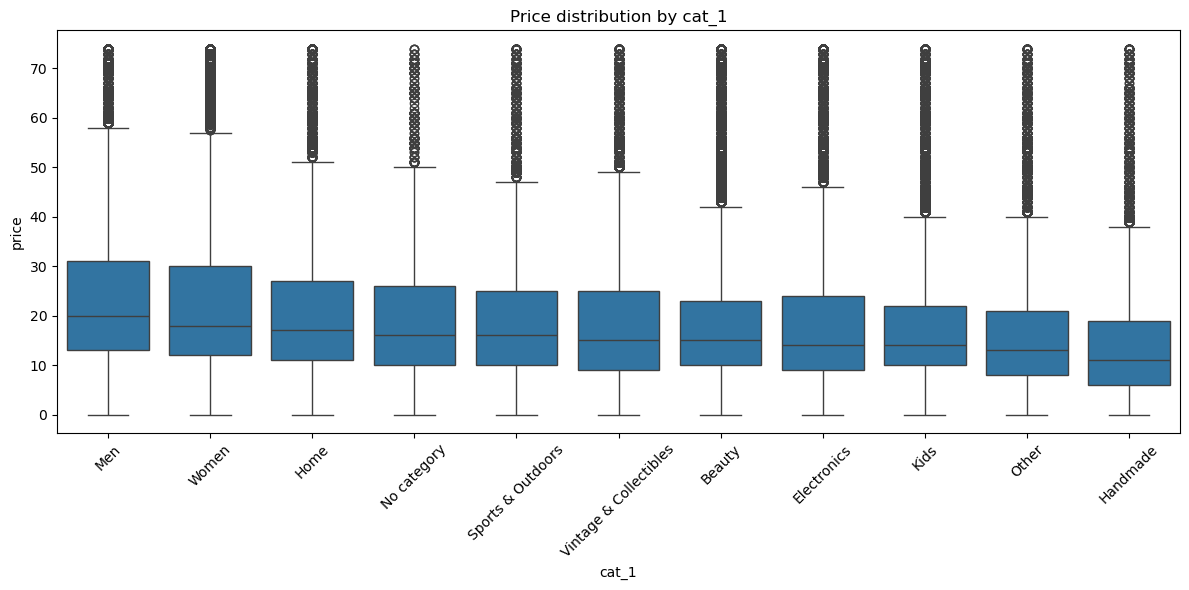

In [36]:
# 대분류 카테고리별 중앙값 가격 비교
cat1_price = train.groupby('cat_1')['price'].median().sort_values(ascending=False)
print(cat1_price)

# 시각화
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=train[train['price'] < train['price'].quantile(0.95)],  # 극단값 제외
    x='cat_1', 
    y='price',
    order=cat1_price.index
)
plt.xticks(rotation=45)
plt.title('Price distribution by cat_1')
plt.tight_layout()
plt.show()

In [37]:
# 수치로도 비교
print("=== 상위 5% 제외 시 가격 통계 ===")
print(train[train['price'] < train['price'].quantile(0.95)].groupby('cat_1')['price'].describe().round(1))

print("\n=== 전체 데이터 가격 통계 ===")
print(train.groupby('cat_1')['price'].describe().round(1))

=== 상위 5% 제외 시 가격 통계 ===
                           count  mean   std  min   25%   50%   75%   max
cat_1                                                                    
Beauty                  204350.0  17.9  11.9  0.0  10.0  15.0  23.0  74.0
Electronics             110002.0  18.6  14.5  0.0   9.0  14.0  24.0  74.0
Handmade                 29958.0  14.9  12.4  0.0   6.0  11.0  19.0  74.0
Home                     65679.0  21.4  13.8  0.0  11.0  17.0  27.0  74.0
Kids                    166947.0  17.8  12.2  0.0  10.0  14.0  22.0  74.0
Men                      84744.0  24.4  15.5  0.0  13.0  20.0  31.0  74.0
No category               6044.0  20.1  13.6  0.0  10.0  16.0  26.0  74.0
Other                    43884.0  17.1  13.0  0.0   8.0  13.0  21.0  74.0
Sports & Outdoors        23931.0  20.1  13.7  0.0  10.0  16.0  25.0  74.0
Vintage & Collectibles   44040.0  19.1  14.0  0.0   9.0  15.0  25.0  74.0
Women                   627415.0  22.7  14.8  0.0  12.0  18.0  30.0  74.0

=== 전체 데이터 가

In [38]:
# 결측 카테고리 상품들 — 다른 컬럼으로 패턴 파악
print(f"Missing category_name Ratio: {len(no_category)/len(train)*100:.2f}%")

# 브랜드와의 관계: 카테고리 없는 상품과 브랜드와의 관계 확인
print("\nBrand Status:")
print(no_category['brand_name'].value_counts().head(10))

# 가격 분포 비교
print("\nPrice Statistics:")
print(pd.DataFrame({
    'category(o)': train[train['cat_1'] != 'No category']['price'].describe(),
    'category(x)': no_category['price'].describe()
}))

Missing category_name Ratio: 0.43%

Brand Status:
brand_name
No Brand             3457
PINK                  158
LuLaRoe               151
Victoria's Secret     101
Nike                   83
FOREVER 21             81
Pokemon                79
Disney                 75
American Eagle         68
Brandy Melville        44
Name: count, dtype: int64

Price Statistics:
        category(o)  category(x)
count  1.476208e+06  6327.000000
mean   2.674327e+01    25.394658
std    3.860403e+01    34.114422
min    0.000000e+00     0.000000
25%    1.000000e+01    10.000000
50%    1.700000e+01    16.000000
75%    2.900000e+01    28.000000
max    2.009000e+03  1000.000000


- 'Electronics'는 중앙값이 15이며, 전체 데이터의 평균값과 상위 5%를 제외한 데이터의 평균값의 차이가 16.6이며 std 역시 압도적으로 크다. 이는 저가 상품과 고가 상품이 혼재되어 있는 것으로 추정할 수 있다.   이를 토대로 'cat_2','cat_3' 세분화된 분석이 필요할 것으로 보인다.  
- 추가적으로 'Men'과 'Vintage & Collectibles' 역시 std 가 41.2와 53.5로 가격 분포가 넓은 것으로 보아 저가부터 고가의 제품이 혼재된 것으로 추정할 수 있다.  
- 카테고리 결측과 브랜드 결측은 동반되는 경향을 보인다.  
- 카테고리가 누락된 6,327건의 데이터에서 상위 브랜드명을 추출한 결과, 여성브랜드인 'PINK','LuLaRoe',"Victoria's Secret','Forever 21' 등 항목이 높은 것을 확인할 수 있다. 결측 카테고리에 많은 부분이 'Women'일 가능성을 확인할 수 있다. 

In [39]:
train.head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand,cat_1,cat_2,cat_3,log_price,name_len,desc_len
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,No Brand,10.0,1,No description yet,0,Men,Tops,T-shirts,2.397895,35,18
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...,1,Electronics,Computers & Tablets,Components & Parts,3.970292,32,188
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...,1,Women,Tops & Blouses,Blouse,2.397895,14,124
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,No Brand,35.0,1,New with tags. Leather horses. Retail for [rm]...,0,Home,Home Décor,Home Décor Accents,3.583519,21,173
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,No Brand,44.0,0,Complete with certificate of authenticity,0,Women,Jewelry,Necklaces,3.806662,20,41


## Beauty 카테고리 name & description 자연어 정제

In [42]:
# Beauty 카테고리만 추출
train_beauty = train[train['cat_1'] == 'Beauty'].copy()

print(train_beauty.shape)
print(train_beauty['cat_1'].value_counts())

(207828, 15)
cat_1
Beauty    207828
Name: count, dtype: int64


In [43]:
train_beauty.head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand,cat_1,cat_2,cat_3,log_price,name_len,desc_len
10,10,Smashbox primer,2,Beauty/Makeup/Face,Smashbox,8.0,1,0.25 oz Full size is 1oz for [rm] in Sephora,1,Beauty,Makeup,Face,2.197225,15,44
11,11,New vs pi k body mists,1,Beauty/Fragrance/Women,Victoria's Secret,34.0,0,(5) new vs pink body mists (2.5 oz each) Fresh...,1,Beauty,Fragrance,Women,3.555348,22,108
15,15,Sephora tarte birthday gift,1,Beauty/Makeup/Makeup Sets,Tarte,11.0,1,Brand new. Deluxe travel size products. Contai...,1,Beauty,Makeup,Makeup Sets,2.484907,27,151
16,16,Glitter Eyeshadow,1,Beauty/Makeup/Eyes,Wet n Wild,6.0,1,2 glitter eyeshadows; one in Brass and one in ...,1,Beauty,Makeup,Eyes,1.945910,17,55
18,18,"Too Faced Limited ""Merry Macaroons""",1,Beauty/Makeup/Makeup Palettes,Too Faced,25.0,1,This AUTHENTIC pallete by Too Faced is brand n...,1,Beauty,Makeup,Makeup Palettes,3.258097,35,307


### name

In [46]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np

vectorizer = CountVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    stop_words='english'
)
X_name = vectorizer.fit_transform(train_beauty['name'].fillna(""))
name_counts = np.array(X_name.sum(axis=0)).ravel()

feature_names = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    "token": feature_names,
    "count": name_counts
}).sort_values("count", ascending=False)

print(freq_df.head(30))

             token  count
6295        bundle  16453
27736          new  13270
29852      palette  11481
37694          set  10747
22399          lip   9957
24552       makeup   7964
5030          body   7866
22817     lipstick   7105
15526   foundation   6876
30706      perfume   6780
15743         free   6731
6024         brush   6091
25196        matte   5807
21078        kylie   5747
14144    eyeshadow   5576
20680          kit   5452
24080          mac   5271
3271          bath   5099
14390        faced   5067
46494        urban   4761
11409        decay   4727
46497  urban decay   4708
43702        tarte   4424
23040       liquid   4307
10381        cream   4300
38765         ship   4268
15782    free ship   4177
3609        beauty   4168
36985       secret   4111
32078       powder   4051


### name 정제 코드

In [161]:
import re

remove_words_name = [
    "bundle", "set", "kit",
    "new","lot", "cosmetics", "rm",
    "price","shipping","freeship","bundle",
    "freeship", "beauty", "mini", "glow",
    "works", "hold"
]

remove_pattern_name = r"\b(" + "|".join(map(re.escape, remove_words_name)) + r")\b"

train_beauty_name_clean = (
    train_beauty["name"]
    .fillna("")
    .str.lower()

    # 기호들 공백으로
    .str.replace(r"[^a-z0-9\s]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()

    # 단어 합치기
    .str.replace(r"\burban\s+decay\b", "urbandecay", regex=True)
    .str.replace(r"\bfree\s+ship(ping)?\b", "freeship", regex=True)
    .str.replace(r"\bvictoria\s*s?\s*secrets?\b", "vs", regex=True)

    # 지정한 단어 제거
    .str.replace(remove_pattern_name, "", regex=True)

    # 공백 정리
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [ ]:
# Beauty name clean 확인
vectorizer = CountVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    stop_words='english'
)

# 여기만 바뀜 (원본 name 대신 clean 사용)
X_name = vectorizer.fit_transform(train_beauty_name_clean)

name_counts = np.array(X_name.sum(axis=0)).ravel()
feature_names = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    "token": feature_names,
    "count": name_counts
}).sort_values("count", ascending=False)

print(freq_df.head(30))

            token  count
33148     palette  11481
26230         lip   9957
28267      makeup   7965
5950         body   7866
47803          vs   7196
26664    lipstick   7105
19539  foundation   6876
33952     perfume   6780
7687        brush   6091
28912       matte   5807
24690       kylie   5747
17723   eyeshadow   5576
27797         mac   5271
4296         bath   5099
18081       faced   5067
46573  urbandecay   4743
43854       tarte   4424
26886      liquid   4307
12930       cream   4301
35238      powder   4051
17232         eye   3846
28700     mascara   3722
34419        pink   3653
27275      lotion   3501
4299    bath body   3490
21398        hair   3308
30775        nail   3302
3024    anastasia   3298
26528    lipsense   3285
5340        black   3253


### item_description

In [ ]:
vectorizer = CountVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    stop_words='english'
)
X_name = vectorizer.fit_transform(train_beauty['item_description'].fillna(""))
name_counts = np.array(X_name.sum(axis=0)).ravel()

feature_names = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    "token": feature_names,
    "count": name_counts
}).sort_values("count", ascending=False)

print(freq_df.head(30))

               token   count
29470            new  108645
6432           brand   63879
6464       brand new   60175
47341           used   57262
37715             rm   56375
17602           free   49527
40718       shipping   47109
9598           color   32612
31437             oz   31611
34763          price   31410
41735           skin   27797
3523       authentic   27716
6146             box   26904
17749  free shipping   26345
41398           size   25360
7371          bundle   25196
6932           brush   22178
26612         makeup   20963
16715           firm   20844
24711            lip   20400
27269          matte   19773
32123        palette   17737
5712            body   16863
246              100   15613
10037         colors   15248
34806     price firm   15064
39696            set   14969
22232          items   14761
47140            use   14496
24991       lipstick   14261


### item_description 정제 코드

In [164]:
import re

remove_words = [
    "condition","great","good","excellent",
    "worn","used","new","like","firm", "rm",
    "price","shipping","freeship","bundle",
    "tags","tag","brandnew", "description",
    "authentic","free","just","use","items","box",
    "ml","oz","fl","g","gram","grams","100", "size", "ship",
    "product","includes","save","beauty","day", "set",
    "comes", "make", "10", "don", "perfect", "item", "long"
]

remove_pattern = r"\b(" + "|".join(map(re.escape, remove_words)) + r")\b"

train_beauty_description_clean = (
    train_beauty["item_description"]
    .fillna("")
    .str.lower()
    
    # 기호들 공백으로
    .str.replace(r"[^a-z0-9\s]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()

    # 단어 합치기
    .str.replace(r"\bbrand\s+new\b", "brandnew", regex=True)
    .str.replace(r"\bfree\s+ship(ping)?\b", "freeship", regex=True)

    # 지정한 단어 제거
    .str.replace(remove_pattern, "", regex=True)

    # 공백 정리
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [ ]:
# Beauty description clean 확인
vectorizer = CountVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    stop_words='english'
)

# 여기만 바뀜 (원본 name 대신 clean 사용)
X_name = vectorizer.fit_transform(train_beauty_description_clean)

name_counts = np.array(X_name.sum(axis=0)).ravel()
feature_names = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    "token": feature_names,
    "count": name_counts
}).sort_values("count", ascending=False)

print(freq_df.head(30))

            token  count
9562        color  32613
41657        skin  27798
6650        brush  22178
27386      makeup  20982
25233         lip  20400
28167       matte  19773
32780     palette  17737
5578         body  16863
10070      colors  15248
25552    lipstick  14261
40449       shade  14170
15837         eye  14116
4842        black  13938
39624      sealed  12664
34303        pink  12506
25737      liquid  11946
11734       cream  11805
20147        hair  11629
16177   eyeshadow  11609
35152      powder  10748
17961  foundation  10329
44591    swatched   9960
24816       light   9954
31419         oil   9882
16291        face   9860
31734      opened   9760
30192     natural   9554
4135         bath   9047
40621      shades   7927
46459      travel   7885
